In [3]:

!pip install pandas==2.1.4
!pip install scikit-learn==1.4.2
!pip install category_encoders==2.6.3

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    RandomizedSearchCV
)

from sklearn.preprocessing import (
    StandardScaler,
    LabelEncoder
)
!pip install category_encoders
from category_encoders import TargetEncoder

from sklearn.linear_model import (
    LinearRegression,
    Ridge,
    Lasso,
    ElasticNet
)

from sklearn.tree import DecisionTreeRegressor

from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor,
    AdaBoostRegressor,
    BaggingRegressor,
    StackingRegressor
)

from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

import joblib

In [4]:
df=pd.read_csv("E:\data science\capstone 1\house price prediction.csv")
df.head(5)

,POSTED_BY,UNDER_CONSTRUCTION,RERA,BHK_NO.,BHK_OR_RK,SQUARE_FT,READY_TO_MOVE,RESALE,ADDRESS,LONGITUDE,LATITUDE,TARGET(PRICE_IN_LACS)
0,Owner,0,0,2,BHK,1300.236407,1,1,"Ksfc Layout,Bangalore",12.969910,77.597960,55.0
1,Dealer,0,0,2,BHK,1275.000000,1,1,"Vishweshwara Nagar,Mysore",12.274538,76.644605,51.0
2,Owner,0,0,2,BHK,933.159722,1,1,"Jigani,Bangalore",12.778033,77.632191,43.0
3,Owner,0,1,2,BHK,929.921143,1,1,"Sector-1 Vaishali,Ghaziabad",28.642300,77.344500,62.5
4,Dealer,1,0,2,BHK,999.009247,0,1,"New Town,Kolkata",22.592200,88.484911,60.5


In [5]:
print(df.shape)
print(df.size)
print(df.info)

print(df.isnull().sum().sum())
print(df.duplicated().sum())


(29451, 12)
353412
<bound method DataFrame.info of       POSTED_BY  UNDER_CONSTRUCTION  RERA  BHK_NO. BHK_OR_RK    SQUARE_FT  \
0         Owner                   0     0        2       BHK  1300.236407   
1        Dealer                   0     0        2       BHK  1275.000000   
2         Owner                   0     0        2       BHK   933.159722   
3         Owner                   0     1        2       BHK   929.921143   
4        Dealer                   1     0        2       BHK   999.009247   
...         ...                 ...   ...      ...       ...          ...   
29446     Owner                   0     0        3       BHK  2500.000000   
29447     Owner                   0     0        2       BHK   769.230769   
29448    Dealer                   0     0        2       BHK  1022.641509   
29449     Owner                   0     0        2       BHK   927.079009   
29450    Dealer                   0     1        2       BHK   896.774194   

       READY_TO_MOVE  RE

In [6]:
df=df.drop_duplicates()

In [7]:
df.describe()

,UNDER_CONSTRUCTION,RERA,BHK_NO.,SQUARE_FT,READY_TO_MOVE,RESALE,LONGITUDE,LATITUDE,TARGET(PRICE_IN_LACS)
count,29050.000000,29050.000000,29050.000000,2.905000e+04,29050.000000,29050.000000,29050.000000,29050.000000,29050.000000
mean,0.178967,0.315869,2.390809,2.003171e+04,0.821033,0.930361,21.270272,76.829585,141.712677
std,0.383332,0.464869,0.880677,1.914411e+06,0.383332,0.254541,6.195973,10.567572,650.055763
min,0.000000,0.000000,1.000000,3.000000e+00,0.000000,0.000000,-37.713008,-121.761248,0.250000
25%,0.000000,0.000000,2.000000,9.000000e+02,1.000000,1.000000,18.452663,73.794800,38.000000
50%,0.000000,0.000000,2.000000,1.172742e+03,1.000000,1.000000,20.631532,77.322873,61.750000
75%,0.000000,1.000000,3.000000,1.550169e+03,1.000000,1.000000,26.886881,77.912934,100.000000
max,1.000000,1.000000,20.000000,2.545455e+08,1.000000,1.000000,59.912884,152.962676,30000.000000


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 29050 entries, 0 to 29450
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   POSTED_BY              29050 non-null  object 
 1   UNDER_CONSTRUCTION     29050 non-null  int64  
 2   RERA                   29050 non-null  int64  
 3   BHK_NO.                29050 non-null  int64  
 4   BHK_OR_RK              29050 non-null  object 
 5   SQUARE_FT              29050 non-null  float64
 6   READY_TO_MOVE          29050 non-null  int64  
 7   RESALE                 29050 non-null  int64  
 8   ADDRESS                29050 non-null  object 
 9   LONGITUDE              29050 non-null  float64
 10  LATITUDE               29050 non-null  float64
 11  TARGET(PRICE_IN_LACS)  29050 non-null  float64
dtypes: float64(4), int64(5), object(3)
memory usage: 2.9+ MB


In [9]:
df = pd.get_dummies(df,columns=["POSTED_BY", "BHK_OR_RK"],drop_first=True)

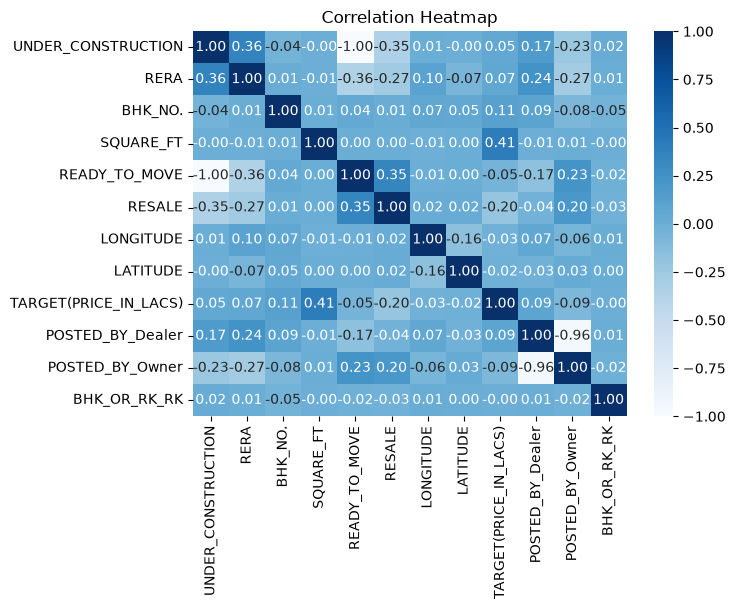

In [10]:
plt.figure(figsize=(7,5))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='Blues', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

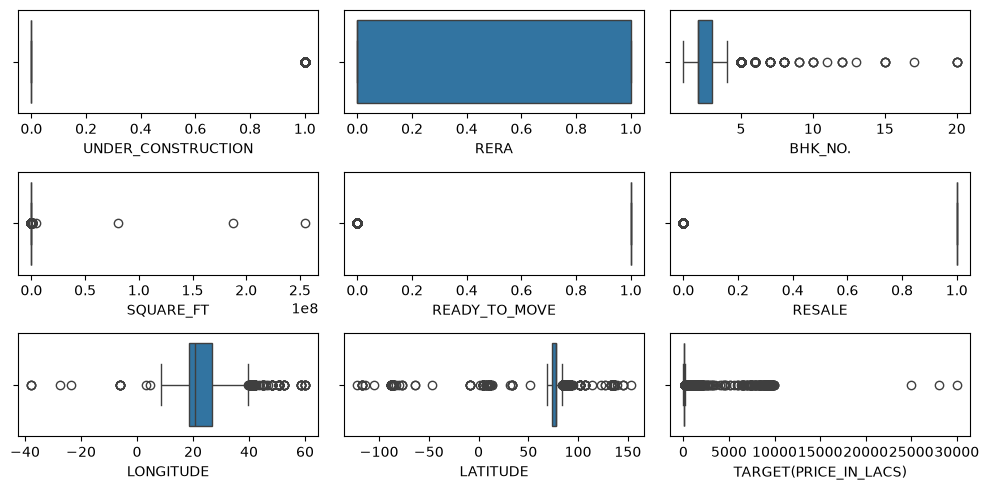

In [11]:
num_cols = df.select_dtypes(include=np.number).columns

plt.figure(figsize=(10,5))

for i,col in enumerate(num_cols):

    plt.subplot(3,3,i+1)
    sns.boxplot(x=df[col])

plt.tight_layout()
plt.show()

In [12]:
corr = df.corr(numeric_only=True)
corr["TARGET(PRICE_IN_LACS)"].sort_values(ascending=False)

TARGET(PRICE_IN_LACS)    1.000000
SQUARE_FT                0.409571
BHK_NO.                  0.113654
POSTED_BY_Dealer         0.085308
RERA                     0.067314
UNDER_CONSTRUCTION       0.054618
BHK_OR_RK_RK            -0.004453
LATITUDE                -0.017813
LONGITUDE               -0.030505
READY_TO_MOVE           -0.054618
POSTED_BY_Owner         -0.093488
RESALE                  -0.203275
Name: TARGET(PRICE_IN_LACS), dtype: float64

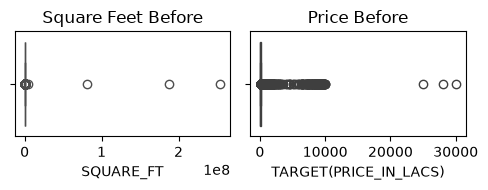

In [13]:
plt.figure(figsize=(5,2))

plt.subplot(1,2,1)
sns.boxplot(x=df["SQUARE_FT"],color="red")
plt.title("Square Feet Before")

plt.subplot(1,2,2)
sns.boxplot(x=df["TARGET(PRICE_IN_LACS)"])
plt.title("Price Before")

plt.tight_layout()
plt.show()

In [14]:
cols = ["SQUARE_FT","BHK_NO."]

for col in cols:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5*IQR
    upper = Q3 + 1.5*IQR

    df[col] = df[col].clip(lower,upper)

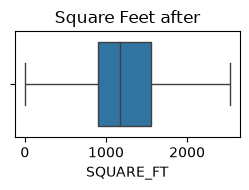

In [15]:
plt.figure(figsize=(5,2))

plt.subplot(1,2,1)
sns.boxplot(x=df["SQUARE_FT"])
plt.title("Square Feet after")

plt.tight_layout()
plt.show()

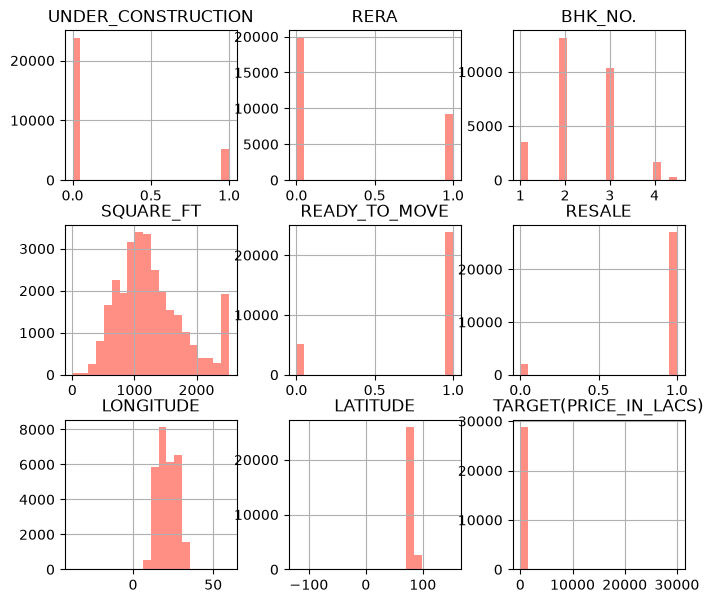

In [16]:
df.hist(figsize=(8,7),bins=20,color='#FF8F85')
plt.show()

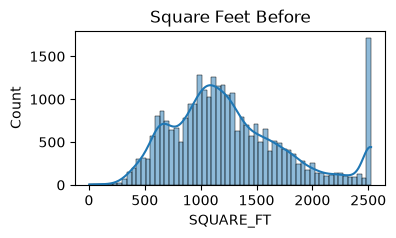

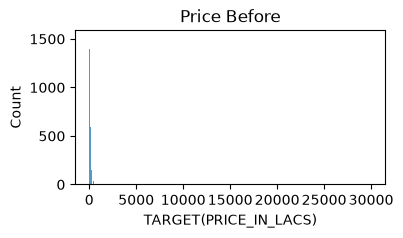

In [17]:
plt.figure(figsize=(4,2))
sns.histplot(df["SQUARE_FT"],kde=True)
plt.title("Square Feet Before")
plt.show()

plt.figure(figsize=(4,2))
sns.histplot(df["TARGET(PRICE_IN_LACS)"])
plt.title("Price Before")
plt.show()


In [18]:
skewness = df.skew(numeric_only=True).sort_values(ascending=False)
print (skewness)


BHK_OR_RK_RK             34.749708
TARGET(PRICE_IN_LACS)    17.971976
UNDER_CONSTRUCTION        1.675076
RERA                      0.792238
SQUARE_FT                 0.740719
POSTED_BY_Owner           0.581496
LONGITUDE                 0.185040
BHK_NO.                   0.176133
POSTED_BY_Dealer         -0.486961
READY_TO_MOVE            -1.675076
RESALE                   -3.381700
LATITUDE                -10.322082
dtype: float64


In [19]:
skewed_columns=["SQUARE_FT","BHK_NO."]

for i in skewed_columns:
   df[i]=np.log1p(df[i])
df[skewed_columns].skew()

SQUARE_FT   -0.794125
BHK_NO.     -0.438341
dtype: float64

In [20]:
# i used it bcoz for accuracy
df["TARGET(PRICE_IN_LACS)"] = np.log1p(df["TARGET(PRICE_IN_LACS)"])

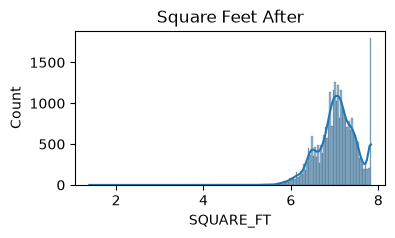

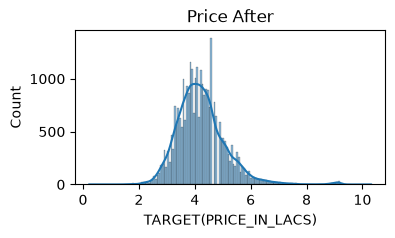

In [21]:
plt.figure(figsize=(4,2))
sns.histplot(df["SQUARE_FT"], kde=True)
plt.title("Square Feet After")
plt.show()

plt.figure(figsize=(4,2))
sns.histplot(df["TARGET(PRICE_IN_LACS)"], kde=True)
plt.title("Price After")
plt.show()


In [22]:
print(df[["SQUARE_FT",
          "TARGET(PRICE_IN_LACS)",
          "BHK_NO."]].skew())

SQUARE_FT               -0.794125
TARGET(PRICE_IN_LACS)    1.202083
BHK_NO.                 -0.438341
dtype: float64


In [23]:
target_cols = ["ADDRESS"]

te = TargetEncoder(cols=target_cols)

df[target_cols] = te.fit_transform(
    df[target_cols],
    df["TARGET(PRICE_IN_LACS)"]
)


In [24]:
x = df.drop("TARGET(PRICE_IN_LACS)", axis=1)

y = df["TARGET(PRICE_IN_LACS)"]

print(x.shape)
print(y.shape)

(29050, 12)
(29050,)


In [25]:
x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.20,
    random_state=42
)

print("Training Shape :", x_train.shape)
print("Testing Shape :", x_test.shape)

Training Shape : (23240, 12)
Testing Shape : (5810, 12)


In [26]:
scaler = StandardScaler()

scale_cols = [
    "SQUARE_FT",
    "BHK_NO.",
    "LONGITUDE",
    "LATITUDE"
]

x_train[scale_cols] = scaler.fit_transform(x_train[scale_cols])

x_test[scale_cols] = scaler.transform(x_test[scale_cols])

In [27]:
def evaluate_model(name, model):

    model.fit(x_train, y_train)

    train_pred = model.predict(x_train)
    test_pred = model.predict(x_test)

    train_r2 = r2_score(y_train, train_pred)
    test_r2 = r2_score(y_test, test_pred)

    train_rmse = np.sqrt(mean_squared_error(y_train, train_pred))
    test_rmse = np.sqrt(mean_squared_error(y_test, test_pred))

    train_mae = mean_absolute_error(y_train, train_pred)
    test_mae = mean_absolute_error(y_test, test_pred)

    print("="*50)
    print(name)
    print("="*50)

    print("Train R2 :", round(train_r2,4))
    print("Test R2  :", round(test_r2,4))

    print()

    print("Train MAE :", round(train_mae,3))
    print("Test MAE  :", round(test_mae,3))

    print()

    print("Train RMSE :", round(train_rmse,3))
    print("Test RMSE  :", round(test_rmse,3))

    print("="*50)

In [28]:
models = {

    "Linear Regression": LinearRegression(),

    "Ridge Regression": Ridge(alpha=1.0),

    "Lasso Regression": Lasso(alpha=0.001),

    "ElasticNet": ElasticNet(alpha=0.001, l1_ratio=0.5),

    "Decision Tree": DecisionTreeRegressor(random_state=42),

    "Random Forest": RandomForestRegressor(random_state=42),

    "Gradient Boosting": GradientBoostingRegressor(random_state=42),

    "AdaBoost": AdaBoostRegressor(random_state=42),

    "KNN": KNeighborsRegressor(),

    "SVR": SVR(),

    "XGBoost": XGBRegressor(random_state=42),

    "LightGBM": LGBMRegressor(random_state=42),

    "CatBoost": CatBoostRegressor(verbose=0, random_state=42)

}

In [29]:
results = []

for name, model in models.items():

    model.fit(x_train, y_train)

    train_pred = model.predict(x_train)

    test_pred = model.predict(x_test)

    train_r2 = r2_score(y_train, train_pred)

    test_r2 = r2_score(y_test, test_pred)

    train_rmse = np.sqrt(
        mean_squared_error(y_train, train_pred)
    )

    test_rmse = np.sqrt(
        mean_squared_error(y_test, test_pred)
    )

    train_mae = mean_absolute_error(
        y_train,
        train_pred
    )

    test_mae = mean_absolute_error(
        y_test,
        test_pred
    )

    results.append({

        "Model": name,

        "Train R2": train_r2,

        "Test R2": test_r2,

        "Train MAE": train_mae,

        "Test MAE": test_mae,

        "Train RMSE": train_rmse,

        "Test RMSE": test_rmse

    })

    print(name,"Completed")

Linear Regression Completed
Ridge Regression Completed
Lasso Regression Completed
ElasticNet Completed
Decision Tree Completed
Random Forest Completed
Gradient Boosting Completed
AdaBoost Completed
KNN Completed
SVR Completed
XGBoost Completed
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001497 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1039
[LightGBM] [Info] Number of data points in the train set: 23240, number of used features: 12
[LightGBM] [Info] Start training from score 4.231218
LightGBM Completed
CatBoost Completed


In [30]:
results_df = pd.DataFrame(results)

results_df

,Model,Train R2,Test R2,Train MAE,Test MAE,Train RMSE,Test RMSE
0,Linear Regression,0.676661,0.664551,0.348580,0.349641,0.501774,0.513599
1,Ridge Regression,0.676664,0.664538,0.348545,0.349626,0.501772,0.513609
2,Lasso Regression,0.676020,0.663908,0.348443,0.349307,0.502271,0.514091
3,ElasticNet,0.676318,0.664182,0.348369,0.349338,0.502040,0.513881
4,Decision Tree,0.997880,0.820337,0.003504,0.233345,0.040630,0.375872
5,Random Forest,0.984140,0.892763,0.067208,0.180193,0.111129,0.290391
6,Gradient Boosting,0.858234,0.851705,0.230461,0.234963,0.332250,0.341487
7,AdaBoost,0.631550,0.618716,0.399370,0.401581,0.535634,0.547564
8,KNN,0.878927,0.804182,0.206400,0.258572,0.307046,0.392407
9,SVR,0.751738,0.729654,0.293302,0.301070,0.439678,0.461074


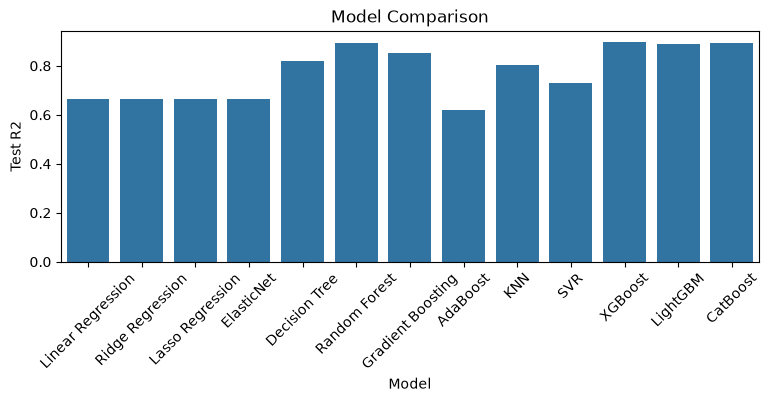

In [31]:
plt.figure(figsize=(9,3))

sns.barplot(
    data=results_df,
    x="Model",
    y="Test R2"
)

plt.xticks(rotation=45)

plt.title("Model Comparison")

plt.show()

In [32]:
params = {
    "n_estimators": [300, 500, 700, 1000],
    "max_depth": [3, 4, 5, 6, 7],
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "subsample": [0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.7, 0.8, 0.9, 1.0],
    "min_child_weight": [1, 2, 3, 5]
}

xgb = XGBRegressor(
    objective="reg:squarederror",
    random_state=42
)

random_search = RandomizedSearchCV(
    xgb,
    param_distributions=params,
    n_iter=20,
    scoring="r2",
    cv=5,
    random_state=42,
    n_jobs=-1
)

random_search.fit(x_train, y_train)

print(random_search.best_params_)
print(random_search.best_score_)

{'subsample': 0.9, 'n_estimators': 700, 'min_child_weight': 1, 'max_depth': 7, 'learning_rate': 0.03, 'colsample_bytree': 1.0}
0.9004744051241926


In [33]:
model = XGBRegressor(
    n_estimators=1200,
    learning_rate=0.02,
    max_depth=5,
    min_child_weight=1,
    subsample=0.9,
    colsample_bytree=0.9,
    gamma=0,
    reg_alpha=0.1,
    reg_lambda=2,
    objective="reg:squarederror",
    random_state=42
)

evaluate_model("XGBoost Tuned", model)

XGBoost Tuned
Train R2 : 0.9211
Test R2  : 0.8946

Train MAE : 0.174
Test MAE  : 0.192

Train RMSE : 0.248
Test RMSE  : 0.288


In [34]:
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBRegressor

# Hyperparameter Grid
params = {
    "n_estimators": [500, 700, 900, 1200],
    "learning_rate": [0.01, 0.03, 0.05],
    "max_depth": [4, 5, 6, 7],
    "subsample": [0.8, 0.9, 1.0],
    "colsample_bytree": [0.8, 0.9, 1.0],
    "min_child_weight": [1, 2, 3],
    "gamma": [0, 0.1, 0.3]
}

# Base Model
xgb = XGBRegressor(
    objective="reg:squarederror",
    random_state=42
)

# Random Search
random_search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=params,
    n_iter=30,      # 30 combinations try karega
    scoring="r2",
    cv=5,
    random_state=42,
    n_jobs=-1,
    verbose=2
)

# Train
random_search.fit(x_train, y_train)

# Best Parameters
print("Best Parameters:")
print(random_search.best_params_)

print("\nBest CV Score:")
print(random_search.best_score_)

# Best Model
best_xgb = random_search.best_estimator_

# Evaluate
evaluate_model("Tuned XGBoost", best_xgb)

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best Parameters:
{'subsample': 0.8, 'n_estimators': 1200, 'min_child_weight': 1, 'max_depth': 7, 'learning_rate': 0.03, 'gamma': 0, 'colsample_bytree': 1.0}

Best CV Score:
0.9024418963008275
Tuned XGBoost
Train R2 : 0.9666
Test R2  : 0.9071

Train MAE : 0.116
Test MAE  : 0.173

Train RMSE : 0.161
Test RMSE  : 0.27


In [39]:
random_search.fit(x_train, y_train)
print(random_search.best_params_)
print(random_search.best_score_)
best_rf = random_search.best_estimator_

evaluate_model("Random Forest Tuned", best_rf)

Fitting 5 folds for each of 30 candidates, totalling 150 fits
{'subsample': 0.8, 'n_estimators': 1200, 'min_child_weight': 1, 'max_depth': 7, 'learning_rate': 0.03, 'gamma': 0, 'colsample_bytree': 1.0}
0.9024418963008275
Random Forest Tuned
Train R2 : 0.9666
Test R2  : 0.9071

Train MAE : 0.116
Test MAE  : 0.173

Train RMSE : 0.161
Test RMSE  : 0.27


In [47]:
from sklearn.ensemble import StackingRegressor
from sklearn.linear_model import Ridge

estimators = [
    ("rf", best_rf),
    ("xgb", best_model),
    ("cat", cat)
]

stack = StackingRegressor(
    estimators=estimators,
    final_estimator=Ridge()
)

stack.fit(x_train, y_train)

evaluate_model("Stacking", stack)

NameError: name 'best_model' is not defined

In [41]:
random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_grid,
    n_iter=10,      
    cv=3,           
    scoring="r2",
    random_state=42,
    n_jobs=-1,
    verbose=2
)

NameError: name 'rf' is not defined

In [44]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor

param_grid = {
    "n_estimators": [100, 200, 300, 400, 500],
    "max_depth": [15, 20, 25, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"],
    "bootstrap": [True]
}

rf = RandomForestRegressor(random_state=42)

random_search = RandomizedSearchCV(
    rf,
    param_distributions=param_grid,
    n_iter=30,
    cv=5,
    scoring="r2",
    random_state=42,
    n_jobs=-1
)

random_search.fit(x_train, y_train)

best_rf = random_search.best_estimator_

evaluate_model("Random Forest Tuned", best_rf)

Random Forest Tuned
Train R2 : 0.9807
Test R2  : 0.8914

Train MAE : 0.08
Test MAE  : 0.183

Train RMSE : 0.123
Test RMSE  : 0.292


In [45]:
cat = CatBoostRegressor(
    iterations=1200,
    learning_rate=0.03,
    depth=8,
    loss_function="RMSE",
    random_state=42,
    verbose=0
)

cat.fit(x_train, y_train)

evaluate_model("CatBoost Final", cat)

CatBoost Final
Train R2 : 0.9288
Test R2  : 0.8953

Train MAE : 0.169
Test MAE  : 0.19

Train RMSE : 0.235
Test RMSE  : 0.287


In [50]:
# Final Model
final_model = model

print("Final Model: Tuned XGBoost")

Final Model: Tuned XGBoost


In [51]:
import joblib

joblib.dump(final_model, "house_price_model.pkl")
joblib.dump(scaler, "scaler.pkl")
joblib.dump(te, "target_encoder.pkl")

print("Tuned XGBoost Model Saved Successfully!")


Tuned XGBoost Model Saved Successfully!
